<a href="https://colab.research.google.com/github/b-li111/wrangling/blob/main/Scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Lab:
Pick something else on Craigslist besides used cars: Musical instruments, roommates, antiques, etc. Look at the search page and its source code. Record which fields/data you would like to gather, and what kinds of basic EDA you'd do with it.
Get your search results of interest using requests and extract data from them using beautifulSoup, using code similar to what's above.
Wrangle your data into a dataframe and do some basic descriptions and plots. Try to find some interesting relationships or stories to tell about your data.

I chose to scrape musical instrument listings.I play the violin so this was really interesting to explore. I actually got the violin I played wiht in highschool off Craigslist (I went to the person and tried it first of course, but it was great! And I think it was around $3k-- you never know what oyu can find on Craigslist!)
 I collected each instrument's title, price, year if possible, brand if possible, and link.
After wrangling it into a dataframe, I cleaned price and year values and calculated the instrument's age. Then I looked at the price and age distributions. What I found was that prices ranged from $0 to $12,345, with a median of $275. Most listings were less than $1k. Ages ranged from 2-63 years, with a lot of instruments in the 45-50 range. The average age for an instrument was about 37 years old.
These results would suggest that many listings are for older, potentially even vintage instruments. THose can be more valuable. The price average was also skewed a bit higher due to a few outliers (like a 12k listing). Really interesting overall!


In [1]:
import numpy as np
import pandas as pd
url = 'https://charlottesville.craigslist.org/search/msg'


In [3]:
import requests
from bs4 import BeautifulSoup as soup
url = 'https://charlottesville.craigslist.org/search/msg'
header = {'User-Agent': 'Mozilla/5.0'}

raw = requests.get(url, headers=header)
bsObj = soup(raw.content, 'html.parser')
listings = bsObj.find_all(class_='cl-static-search-result')

print("number of listings found:", len(listings))
print(listings[0].prettify())


number of listings found: 143
<li class="cl-static-search-result" title='Fender "70th Anniversary Esquire" Guitar w/Case! Minty, Hang Tags!'>
 <a href="https://charlottesville.craigslist.org/msg/d/charlottesville-fender-70th-anniversary/7846316163.html">
  <div class="title">
   Fender "70th Anniversary Esquire" Guitar w/Case! Minty, Hang Tags!
  </div>
  <div class="details">
   <div class="price">
    $1,600
   </div>
   <div class="location">
    Charlottesville
   </div>
  </div>
 </a>
</li>



In [4]:
import re

data = []

for k in range(len(listings)):
    title = listings[k].find('div', class_='title').get_text().lower()
    price = listings[k].find('div', class_='price').get_text()
    link = listings[k].find('a', href=True)['href']

    # tried to get the brand by checking  known names in  title
    brands = ['fender', 'gibson', 'yamaha', 'roland', 'korg', 'martin', 'taylor', 'epiphone', 'casio', 'ibanez']
    words = title.split()
    hits = [word for word in words if word in brands]
    if len(hits) == 0:
        brand = 'missing'
    else:
        brand = hits[0]

    regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title)
    if regex_search is None:
        year = np.nan
    else:
        year = regex_search.group(0)

    data.append({'title': title, 'price': price, 'year': year, 'link': link, 'brand': brand})


In [5]:
df = pd.DataFrame.from_dict(data)

df['price'] = df['price'].str.replace('$', '').str.replace(',', '')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['age'] = 2025 - df['year']
df.head()

,title,price,year,link,brand,age
0,"fender ""70th anniversary esquire"" guitar w/cas...",1600,NaN,https://charlottesville.craigslist.org/msg/d/c...,fender,NaN
1,epiphone's newest inspired by gibson custom le...,799,NaN,https://charlottesville.craigslist.org/msg/d/s...,gibson,NaN
2,1994 guild acoustic guitar d4-nt,700,1994.0,https://charlottesville.craigslist.org/msg/d/n...,missing,31.0
3,martin d35 sunburst with fishman pickup,2800,NaN,https://charlottesville.craigslist.org/msg/d/c...,martin,NaN
4,bow re-hair,50,NaN,https://charlottesville.craigslist.org/msg/d/b...,missing,NaN


count      143.000000
mean       610.678322
std       1242.998457
min          0.000000
25%         75.000000
50%        275.000000
75%        650.000000
max      12345.000000
Name: price, dtype: float64


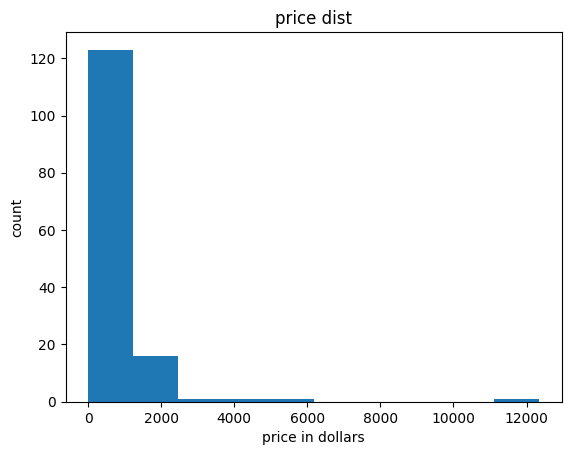

In [7]:
import matplotlib.pyplot as plt
print(df['price'].describe())
df['price'].hist(grid=False)
plt.title("price dist")
plt.xlabel("price in dollars")
plt.ylabel("count")
plt.show()


count    22.000000
mean     36.727273
std      19.383797
min       2.000000
25%      19.750000
50%      46.500000
75%      48.750000
max      63.000000
Name: age, dtype: float64


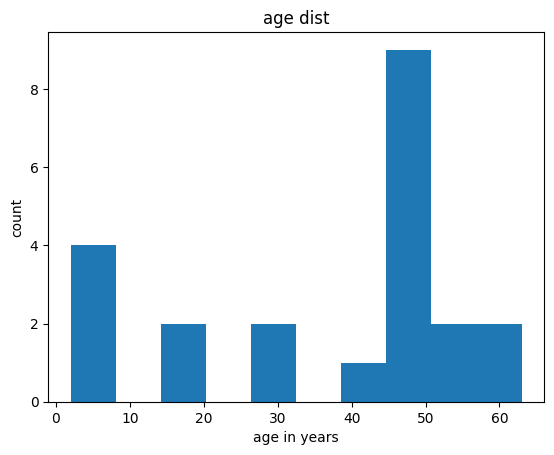

In [8]:
print(df['age'].describe())
df['age'].hist(grid=False)
plt.title("age dist")
plt.xlabel("age in years")
plt.ylabel("count")
plt.show()